# Human Activity and Postural Transition Recognition

This project uses raw accelerometer and gyroscope signals to classify 12 human activities and postural transitions.

The input consists of six sensor features:
- Accelerometer X, Y, Z
- Gyroscope X, Y, Z

The goal is to prepare the raw sensor data for deep learning models and later compare different architectures.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
data_path = r"C:\Users\hp\Downloads\smartphone+based+recognition+of+human+activities+and+postural+transitions"

raw_path = os.path.join(data_path, "RawData")

print("Dataset path:", data_path)
print("Raw data path:", raw_path)

Dataset path: C:\Users\hp\Downloads\smartphone+based+recognition+of+human+activities+and+postural+transitions
Raw data path: C:\Users\hp\Downloads\smartphone+based+recognition+of+human+activities+and+postural+transitions\RawData


In [4]:
print("RawData folder exists:", os.path.exists(raw_path))

files = os.listdir(raw_path)

print("Number of files:", len(files))
print("\nFirst 10 files:")

for file in files[:10]:
    print(file)

RawData folder exists: True
Number of files: 123

First 10 files:
acc_exp01_user01.txt
acc_exp02_user01.txt
acc_exp03_user02.txt
acc_exp04_user02.txt
acc_exp05_user03.txt
acc_exp06_user03.txt
acc_exp07_user04.txt
acc_exp08_user04.txt
acc_exp09_user05.txt
acc_exp10_user05.txt


In [5]:
acc_file = os.path.join(raw_path, "acc_exp01_user01.txt")
gyro_file = os.path.join(raw_path, "gyro_exp01_user01.txt")

acc = np.loadtxt(acc_file)
gyro = np.loadtxt(gyro_file)

print("Accelerometer shape:", acc.shape)
print("Gyroscope shape:", gyro.shape)

Accelerometer shape: (20598, 3)
Gyroscope shape: (20598, 3)


In [6]:
sensor_data = np.concatenate(
    [acc, gyro],
    axis=1
)

print("Combined sensor shape:", sensor_data.shape)
print("\nFirst 5 rows:")
print(sensor_data[:5])

Combined sensor shape: (20598, 6)

First 5 rows:
[[ 0.91805559 -0.1125      0.50972225 -0.05497787 -0.06963864 -0.03084869]
 [ 0.91111113 -0.09305556  0.53750004 -0.01252274  0.01924226 -0.03848451]
 [ 0.8819445  -0.08611111  0.51388893 -0.02351831  0.27641651  0.00641409]
 [ 0.8819445  -0.08611111  0.51388893 -0.09346239  0.36774087  0.00122173]
 [ 0.87916671 -0.1         0.50555558 -0.12431107  0.47678033 -0.02290745]]


In [7]:
labels_path = os.path.join(raw_path, "labels.txt")

labels = np.loadtxt(labels_path, dtype=int)

print("Labels shape:", labels.shape)
print("\nFirst 10 label rows:")
print(labels[:10])

Labels shape: (1214, 5)

First 10 label rows:
[[   1    1    5  250 1232]
 [   1    1    7 1233 1392]
 [   1    1    4 1393 2194]
 [   1    1    8 2195 2359]
 [   1    1    5 2360 3374]
 [   1    1   11 3375 3662]
 [   1    1    6 3663 4538]
 [   1    1   10 4539 4735]
 [   1    1    4 4736 5667]
 [   1    1    9 5668 5859]]


In [8]:
sequence_length = 128

X_sequences = []
y_sequences = []

for label_row in labels:

    experiment = label_row[0]
    user = label_row[1]
    activity = label_row[2]
    start = label_row[3]
    end = label_row[4]

    # We are currently working with experiment 1, user 1
    if experiment == 1 and user == 1:

        # Convert from 1-based dataset indexing to Python indexing
        segment = sensor_data[start - 1:end]

        # Create fixed-length sequences
        for i in range(0, len(segment) - sequence_length + 1, sequence_length):

            sequence = segment[i:i + sequence_length]

            X_sequences.append(sequence)

            # Convert activity labels from 1-12 to 0-11
            y_sequences.append(activity - 1)


X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print("X shape:", X_sequences.shape)
print("y shape:", y_sequences.shape)

X shape: (98, 128, 6)
y shape: (98,)


In [9]:
sequence_length = 128

X_sequences = []
y_sequences = []

# Process every experiment/user combination
for label_row in labels:

    experiment = int(label_row[0])
    user = int(label_row[1])
    activity = int(label_row[2])
    start = int(label_row[3])
    end = int(label_row[4])

    # File names
    acc_file = os.path.join(
        raw_path,
        f"acc_exp{experiment:02d}_user{user:02d}.txt"
    )

    gyro_file = os.path.join(
        raw_path,
        f"gyro_exp{experiment:02d}_user{user:02d}.txt"
    )

    # Load the sensor data
    acc = np.loadtxt(acc_file)
    gyro = np.loadtxt(gyro_file)

    # Combine accelerometer + gyroscope
    sensor_data = np.concatenate(
        [acc, gyro],
        axis=1
    )

    # Extract the labeled activity segment
    segment = sensor_data[start - 1:end]

    # Create fixed-length sequences
    for i in range(
        0,
        len(segment) - sequence_length + 1,
        sequence_length
    ):

        sequence = segment[i:i + sequence_length]

        X_sequences.append(sequence)

        # Convert labels 1-12 → 0-11
        y_sequences.append(activity - 1)


# Convert lists to NumPy arrays
X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print("Full dataset created!")
print("X shape:", X_sequences.shape)
print("y shape:", y_sequences.shape)

Full dataset created!
X shape: (5773, 128, 6)
y shape: (5773,)


In [10]:
print("Class distribution:")

class_counts = Counter(y_sequences)

for class_id in sorted(class_counts):
    print(
        f"Class {class_id}: "
        f"{class_counts[class_id]} samples"
    )

Class distribution:
Class 0: 893 samples
Class 1: 809 samples
Class 2: 747 samples
Class 3: 928 samples
Class 4: 1019 samples
Class 5: 1013 samples
Class 6: 56 samples
Class 7: 33 samples
Class 8: 68 samples
Class 9: 62 samples
Class 10: 84 samples
Class 11: 61 samples


In [11]:
# Rebuild the dataset while keeping the user ID

sequence_length = 128

X_sequences = []
y_sequences = []
user_ids = []

for label_row in labels:

    experiment = int(label_row[0])
    user = int(label_row[1])
    activity = int(label_row[2])
    start = int(label_row[3])
    end = int(label_row[4])

    acc_file = os.path.join(
        raw_path,
        f"acc_exp{experiment:02d}_user{user:02d}.txt"
    )

    gyro_file = os.path.join(
        raw_path,
        f"gyro_exp{experiment:02d}_user{user:02d}.txt"
    )

    acc = np.loadtxt(acc_file)
    gyro = np.loadtxt(gyro_file)

    sensor_data = np.concatenate(
        [acc, gyro],
        axis=1
    )

    segment = sensor_data[start - 1:end]

    for i in range(
        0,
        len(segment) - sequence_length + 1,
        sequence_length
    ):

        sequence = segment[i:i + sequence_length]

        X_sequences.append(sequence)
        y_sequences.append(activity - 1)
        user_ids.append(user)


X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)
user_ids = np.array(user_ids)

print("X shape:", X_sequences.shape)
print("y shape:", y_sequences.shape)
print("User IDs shape:", user_ids.shape)

X shape: (5773, 128, 6)
y shape: (5773,)
User IDs shape: (5773,)


In [12]:
train_users = list(range(1, 22))
val_users = list(range(22, 26))
test_users = list(range(26, 31))

train_mask = np.isin(user_ids, train_users)
val_mask = np.isin(user_ids, val_users)
test_mask = np.isin(user_ids, test_users)

X_train = X_sequences[train_mask]
y_train = y_sequences[train_mask]

X_val = X_sequences[val_mask]
y_val = y_sequences[val_mask]

X_test = X_sequences[test_mask]
y_test = y_sequences[test_mask]

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation set:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (3910, 128, 6)
y_train: (3910,)

Validation set:
X_val: (826, 128, 6)
y_val: (826,)

Test set:
X_test: (1037, 128, 6)
y_test: (1037,)


In [13]:
# Calculate mean and standard deviation from training data only

train_mean = X_train.mean(axis=(0, 1))
train_std = X_train.std(axis=(0, 1))

print("Training mean:")
print(train_mean)

print("\nTraining standard deviation:")
print(train_std)

Training mean:
[ 0.81024464  0.01819943  0.06453241  0.00611857 -0.00490566 -0.00533715]

Training standard deviation:
[0.400874   0.42017309 0.33842082 0.43447253 0.41123155 0.29898904]


In [14]:
# Normalize using training statistics only

X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("Normalization completed!")

print("\nTraining mean after normalization:")
print(X_train.mean(axis=(0, 1)))

print("\nTraining standard deviation after normalization:")
print(X_train.std(axis=(0, 1)))

Normalization completed!

Training mean after normalization:
[ 3.02131996e-13 -1.88839216e-14  1.56369385e-14 -7.38649471e-17
 -9.14163779e-17 -1.51945805e-16]

Training standard deviation after normalization:
[1. 1. 1. 1. 1. 1.]


In [15]:
import torch

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

print("X_val:", X_val_tensor.shape)
print("y_val:", y_val_tensor.shape)

print("X_test:", X_test_tensor.shape)
print("y_test:", y_test_tensor.shape)

X_train: torch.Size([3910, 128, 6])
y_train: torch.Size([3910])
X_val: torch.Size([826, 128, 6])
y_val: torch.Size([826])
X_test: torch.Size([1037, 128, 6])
y_test: torch.Size([1037])


In [16]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 64

# Create datasets
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("DataLoaders created!")
print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches:", len(test_loader))

DataLoaders created!
Number of training batches: 62
Number of validation batches: 13
Number of test batches: 17


In [17]:
# Check one training batch

sample_batch, label_batch = next(iter(train_loader))

print("\nSample batch shape:", sample_batch.shape)
print("Label batch shape:", label_batch.shape)


Sample batch shape: torch.Size([64, 128, 6])
Label batch shape: torch.Size([64])


In [19]:
import torch

# Use GPU if available, otherwise use CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [20]:
import torch.nn as nn


class CNN1D(nn.Module):
    def __init__(self, num_classes=12):
        super(CNN1D, self).__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=6,
                out_channels=64,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),

            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=64,
                out_channels=128,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),

            nn.MaxPool1d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        # [batch, time, features]
        # → [batch, features, time]
        x = x.transpose(1, 2)

        x = self.features(x)

        x = self.classifier(x)

        return x


cnn_model = CNN1D(num_classes=12).to(device)

print(cnn_model)

CNN1D(
  (features): Sequential(
    (0): Conv1d(6, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=12, bias=True)
  )
)


In [21]:
# Count trainable parameters

total_params = sum(
    p.numel()
    for p in cnn_model.parameters()
    if p.requires_grad
)

print("CNN Trainable Parameters:", total_params)

CNN Trainable Parameters: 44620


In [22]:
# Test one forward pass

sample_batch, label_batch = next(iter(train_loader))

sample_batch = sample_batch.to(device)

with torch.no_grad():
    output = cnn_model(sample_batch)

print("Input shape:", sample_batch.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([64, 128, 6])
Output shape: torch.Size([64, 12])


In [23]:
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [24]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=15):

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total


        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        val_loss_total = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for inputs, labels in val_loader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                val_loss_total += loss.item()

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss_total / len(val_loader)
        val_accuracy = 100 * val_correct / val_total


        # Save history
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)


        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {train_loss:.4f} "
            f"Train Acc: {train_accuracy:.2f}% "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_accuracy:.2f}%"
        )

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies
    }

In [25]:
import time

# Start timing
start_time = time.time()

# Train the CNN
cnn_history = train_model(
    cnn_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=15
)

# Training time
cnn_training_time = time.time() - start_time

print("\nCNN Training completed!")
print(f"Training time: {cnn_training_time:.2f} seconds")

Epoch [1/15] Loss: 1.2836 Train Acc: 62.02% Val Loss: 0.5817 Val Acc: 86.08%
Epoch [2/15] Loss: 0.5239 Train Acc: 80.95% Val Loss: 0.3652 Val Acc: 87.29%
Epoch [3/15] Loss: 0.3694 Train Acc: 85.75% Val Loss: 0.3055 Val Acc: 88.50%
Epoch [4/15] Loss: 0.2886 Train Acc: 89.69% Val Loss: 0.2558 Val Acc: 91.65%
Epoch [5/15] Loss: 0.2438 Train Acc: 91.23% Val Loss: 0.2932 Val Acc: 89.47%
Epoch [6/15] Loss: 0.2178 Train Acc: 92.10% Val Loss: 0.2467 Val Acc: 92.62%
Epoch [7/15] Loss: 0.2032 Train Acc: 92.89% Val Loss: 0.2841 Val Acc: 89.59%
Epoch [8/15] Loss: 0.1890 Train Acc: 92.53% Val Loss: 0.2822 Val Acc: 92.01%
Epoch [9/15] Loss: 0.1809 Train Acc: 93.02% Val Loss: 0.2184 Val Acc: 93.22%
Epoch [10/15] Loss: 0.1687 Train Acc: 93.43% Val Loss: 0.2718 Val Acc: 91.53%
Epoch [11/15] Loss: 0.1616 Train Acc: 93.53% Val Loss: 0.2825 Val Acc: 90.92%
Epoch [12/15] Loss: 0.1508 Train Acc: 93.91% Val Loss: 0.2457 Val Acc: 93.22%
Epoch [13/15] Loss: 0.1440 Train Acc: 94.04% Val Loss: 0.3440 Val Acc: 89

In [26]:
cnn_results = {
    "Model": "CNN",
    "Parameters": total_params,
    "Training Time (s)": cnn_training_time,
    "Best Validation Accuracy (%)": max(cnn_history["val_accuracies"]),
    "Final Training Accuracy (%)": cnn_history["train_accuracies"][-1],
    "Final Validation Accuracy (%)": cnn_history["val_accuracies"][-1]
}

print(cnn_results)

{'Model': 'CNN', 'Parameters': 44620, 'Training Time (s)': 32.44960975646973, 'Best Validation Accuracy (%)': 93.58353510895884, 'Final Training Accuracy (%)': 94.11764705882354, 'Final Validation Accuracy (%)': 93.58353510895884}


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

cnn_model.eval()

all_predictions = []
all_labels = []

start_time = time.time()

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)

        outputs = cnn_model(inputs)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

cnn_inference_time = time.time() - start_time

# Calculate metrics
cnn_test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

cnn_precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

cnn_recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

cnn_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print(f"CNN Test Accuracy: {cnn_test_accuracy * 100:.2f}%")
print(f"CNN Precision: {cnn_precision * 100:.2f}%")
print(f"CNN Recall: {cnn_recall * 100:.2f}%")
print(f"CNN F1-Score: {cnn_f1 * 100:.2f}%")
print(f"CNN Inference Time: {cnn_inference_time:.4f} seconds")

CNN Test Accuracy: 93.73%
CNN Precision: 93.99%
CNN Recall: 93.73%
CNN F1-Score: 93.65%
CNN Inference Time: 0.2301 seconds


In [28]:
import os

model_dir = r"D:\deep learning bonus project\models"

os.makedirs(model_dir, exist_ok=True)

torch.save(
    cnn_model.state_dict(),
    os.path.join(model_dir, "cnn_best.pth")
)

print("CNN model saved successfully!")

CNN model saved successfully!


In [29]:
class LSTM_Model(nn.Module):
    def __init__(self, input_size=6, hidden_size=64, num_layers=2, num_classes=12):
        super(LSTM_Model, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):

        # x shape:
        # [batch, time_steps, features]

        lstm_output, (hidden, cell) = self.lstm(x)

        # Use the last time step
        x = lstm_output[:, -1, :]

        # Classification
        x = self.fc(x)

        return x


lstm_model = LSTM_Model().to(device)

print(lstm_model)

LSTM_Model(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=12, bias=True)
)


In [30]:
lstm_params = sum(
    p.numel()
    for p in lstm_model.parameters()
    if p.requires_grad
)

print("LSTM Trainable Parameters:", lstm_params)

LSTM Trainable Parameters: 52492


In [31]:
# Test one forward pass

sample_batch, label_batch = next(iter(train_loader))

sample_batch = sample_batch.to(device)

with torch.no_grad():
    output = lstm_model(sample_batch)

print("Input shape:", sample_batch.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([64, 128, 6])
Output shape: torch.Size([64, 12])


In [32]:
lstm_criterion = nn.CrossEntropyLoss()

lstm_optimizer = optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

print("LSTM loss function:", lstm_criterion)
print("LSTM optimizer:", lstm_optimizer)

LSTM loss function: CrossEntropyLoss()
LSTM optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [33]:
# Train the LSTM

start_time = time.time()

lstm_history = train_model(
    lstm_model,
    train_loader,
    val_loader,
    lstm_criterion,
    lstm_optimizer,
    epochs=15
)

lstm_training_time = time.time() - start_time

print("\nLSTM Training completed!")
print(f"Training time: {lstm_training_time:.2f} seconds")

Epoch [1/15] Loss: 1.8579 Train Acc: 36.98% Val Loss: 1.3544 Val Acc: 56.05%
Epoch [2/15] Loss: 1.2521 Train Acc: 56.52% Val Loss: 1.1117 Val Acc: 64.41%
Epoch [3/15] Loss: 0.9838 Train Acc: 68.85% Val Loss: 1.0249 Val Acc: 66.46%
Epoch [4/15] Loss: 0.8937 Train Acc: 67.60% Val Loss: 0.7219 Val Acc: 73.24%
Epoch [5/15] Loss: 0.7645 Train Acc: 72.10% Val Loss: 0.6289 Val Acc: 77.60%
Epoch [6/15] Loss: 0.6795 Train Acc: 75.52% Val Loss: 0.6728 Val Acc: 83.17%
Epoch [7/15] Loss: 0.6500 Train Acc: 76.85% Val Loss: 0.5527 Val Acc: 83.90%
Epoch [8/15] Loss: 0.6019 Train Acc: 80.90% Val Loss: 0.5271 Val Acc: 81.23%
Epoch [9/15] Loss: 0.5054 Train Acc: 83.40% Val Loss: 0.6073 Val Acc: 71.43%
Epoch [10/15] Loss: 0.5034 Train Acc: 82.94% Val Loss: 0.5226 Val Acc: 83.66%
Epoch [11/15] Loss: 0.7266 Train Acc: 76.75% Val Loss: 0.8535 Val Acc: 75.54%
Epoch [12/15] Loss: 0.6301 Train Acc: 79.97% Val Loss: 0.6580 Val Acc: 77.85%
Epoch [13/15] Loss: 0.5286 Train Acc: 81.84% Val Loss: 0.6227 Val Acc: 82

In [34]:
# Evaluate LSTM on the test set

lstm_model.eval()

all_predictions = []
all_labels = []

start_time = time.time()

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)

        outputs = lstm_model(inputs)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

lstm_inference_time = time.time() - start_time

# Calculate metrics
lstm_test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

lstm_precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

lstm_recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

lstm_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print(f"LSTM Test Accuracy: {lstm_test_accuracy * 100:.2f}%")
print(f"LSTM Precision: {lstm_precision * 100:.2f}%")
print(f"LSTM Recall: {lstm_recall * 100:.2f}%")
print(f"LSTM F1-Score: {lstm_f1 * 100:.2f}%")
print(f"LSTM Inference Time: {lstm_inference_time:.4f} seconds")

LSTM Test Accuracy: 88.43%
LSTM Precision: 87.83%
LSTM Recall: 88.43%
LSTM F1-Score: 87.65%
LSTM Inference Time: 0.2092 seconds


In [35]:
lstm_results = {
    "Model": "LSTM",
    "Parameters": lstm_params,
    "Training Time (s)": lstm_training_time,
    "Best Validation Accuracy (%)": max(lstm_history["val_accuracies"]),
    "Final Training Accuracy (%)": lstm_history["train_accuracies"][-1],
    "Final Validation Accuracy (%)": lstm_history["val_accuracies"][-1],
    "Test Accuracy (%)": lstm_test_accuracy * 100,
    "Precision (%)": lstm_precision * 100,
    "Recall (%)": lstm_recall * 100,
    "F1-Score (%)": lstm_f1 * 100,
    "Inference Time (s)": lstm_inference_time
}

print(lstm_results)

{'Model': 'LSTM', 'Parameters': 52492, 'Training Time (s)': 41.05617880821228, 'Best Validation Accuracy (%)': 84.50363196125907, 'Final Training Accuracy (%)': 85.21739130434783, 'Final Validation Accuracy (%)': 84.50363196125907, 'Test Accuracy (%)': 88.4281581485053, 'Precision (%)': 87.82586263684232, 'Recall (%)': 88.4281581485053, 'F1-Score (%)': 87.65396363022356, 'Inference Time (s)': 0.2091515064239502}


In [36]:
torch.save(
    lstm_model.state_dict(),
    os.path.join(model_dir, "lstm.pth")
)

print("LSTM model saved successfully!")

LSTM model saved successfully!


In [37]:
class GRU_Model(nn.Module):
    def __init__(self, input_size=6, hidden_size=64, num_layers=2, num_classes=12):
        super(GRU_Model, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):

        # x shape:
        # [batch, time_steps, features]

        gru_output, hidden = self.gru(x)

        # Use the last time step
        x = gru_output[:, -1, :]

        # Classification
        x = self.fc(x)

        return x


gru_model = GRU_Model().to(device)

print(gru_model)

GRU_Model(
  (gru): GRU(6, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=12, bias=True)
)


In [38]:
gru_params = sum(
    p.numel()
    for p in gru_model.parameters()
    if p.requires_grad
)

print("GRU Trainable Parameters:", gru_params)

GRU Trainable Parameters: 39564


In [39]:
# Test one forward pass

sample_batch, label_batch = next(iter(train_loader))

sample_batch = sample_batch.to(device)

with torch.no_grad():
    output = gru_model(sample_batch)

print("Input shape:", sample_batch.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([64, 128, 6])
Output shape: torch.Size([64, 12])


In [40]:
gru_criterion = nn.CrossEntropyLoss()

gru_optimizer = optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

print("GRU loss function:", gru_criterion)
print("GRU optimizer:", gru_optimizer)

GRU loss function: CrossEntropyLoss()
GRU optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [41]:
# Train the GRU

start_time = time.time()

gru_history = train_model(
    gru_model,
    train_loader,
    val_loader,
    gru_criterion,
    gru_optimizer,
    epochs=15
)

gru_training_time = time.time() - start_time

print("\nGRU Training completed!")
print(f"Training time: {gru_training_time:.2f} seconds")

Epoch [1/15] Loss: 1.7534 Train Acc: 39.97% Val Loss: 1.2271 Val Acc: 60.90%
Epoch [2/15] Loss: 1.1057 Train Acc: 62.02% Val Loss: 0.7737 Val Acc: 81.36%
Epoch [3/15] Loss: 0.7232 Train Acc: 77.44% Val Loss: 0.5897 Val Acc: 80.99%
Epoch [4/15] Loss: 0.5486 Train Acc: 82.23% Val Loss: 0.4703 Val Acc: 85.84%
Epoch [5/15] Loss: 0.4441 Train Acc: 85.04% Val Loss: 0.4291 Val Acc: 85.96%
Epoch [6/15] Loss: 0.3709 Train Acc: 87.34% Val Loss: 0.3364 Val Acc: 90.07%
Epoch [7/15] Loss: 0.3221 Train Acc: 88.18% Val Loss: 0.3225 Val Acc: 90.19%
Epoch [8/15] Loss: 0.2766 Train Acc: 89.31% Val Loss: 0.3539 Val Acc: 87.77%
Epoch [9/15] Loss: 0.2571 Train Acc: 90.31% Val Loss: 0.2535 Val Acc: 91.77%
Epoch [10/15] Loss: 0.2429 Train Acc: 90.92% Val Loss: 0.2513 Val Acc: 90.56%
Epoch [11/15] Loss: 0.2177 Train Acc: 91.33% Val Loss: 0.2576 Val Acc: 89.71%
Epoch [12/15] Loss: 0.2080 Train Acc: 91.79% Val Loss: 0.2938 Val Acc: 89.35%
Epoch [13/15] Loss: 0.2001 Train Acc: 91.87% Val Loss: 0.2184 Val Acc: 92

In [42]:
# Evaluate GRU on the test set

gru_model.eval()

all_predictions = []
all_labels = []

start_time = time.time()

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)

        outputs = gru_model(inputs)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

gru_inference_time = time.time() - start_time

# Calculate metrics
gru_test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

gru_precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

gru_recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

gru_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print(f"GRU Test Accuracy: {gru_test_accuracy * 100:.2f}%")
print(f"GRU Precision: {gru_precision * 100:.2f}%")
print(f"GRU Recall: {gru_recall * 100:.2f}%")
print(f"GRU F1-Score: {gru_f1 * 100:.2f}%")
print(f"GRU Inference Time: {gru_inference_time:.4f} seconds")

GRU Test Accuracy: 86.69%
GRU Precision: 87.94%
GRU Recall: 86.69%
GRU F1-Score: 86.40%
GRU Inference Time: 0.5538 seconds


In [43]:
gru_results = {
    "Model": "GRU",
    "Parameters": gru_params,
    "Training Time (s)": gru_training_time,
    "Best Validation Accuracy (%)": max(gru_history["val_accuracies"]),
    "Final Training Accuracy (%)": gru_history["train_accuracies"][-1],
    "Final Validation Accuracy (%)": gru_history["val_accuracies"][-1],
    "Test Accuracy (%)": gru_test_accuracy * 100,
    "Precision (%)": gru_precision * 100,
    "Recall (%)": gru_recall * 100,
    "F1-Score (%)": gru_f1 * 100,
    "Inference Time (s)": gru_inference_time
}

print(gru_results)

{'Model': 'GRU', 'Parameters': 39564, 'Training Time (s)': 149.73689723014832, 'Best Validation Accuracy (%)': 92.13075060532688, 'Final Training Accuracy (%)': 92.1227621483376, 'Final Validation Accuracy (%)': 84.62469733656174, 'Test Accuracy (%)': 86.6923818707811, 'Precision (%)': 87.93748908790633, 'Recall (%)': 86.6923818707811, 'F1-Score (%)': 86.39867152986885, 'Inference Time (s)': 0.553837776184082}


In [44]:
torch.save(
    gru_model.state_dict(),
    os.path.join(model_dir, "gru.pth")
)

print("GRU model saved successfully!")

GRU model saved successfully!


In [45]:
class CNN_LSTM_Model(nn.Module):
    def __init__(
        self,
        input_size=6,
        cnn_channels=64,
        hidden_size=64,
        num_layers=2,
        num_classes=12
    ):
        super(CNN_LSTM_Model, self).__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(
            nn.Conv1d(
                in_channels=input_size,
                out_channels=cnn_channels,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),

            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=cnn_channels,
                out_channels=cnn_channels,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU()
        )

        # LSTM sequence model
        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # Classifier
        self.fc = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):

        # Input:
        # [batch, time_steps, features]

        # CNN expects:
        # [batch, features, time_steps]
        x = x.transpose(1, 2)

        # CNN
        x = self.cnn(x)

        # Back to:
        # [batch, time_steps, features]
        x = x.transpose(1, 2)

        # LSTM
        lstm_output, (hidden, cell) = self.lstm(x)

        # Last time step
        x = lstm_output[:, -1, :]

        # Classification
        x = self.fc(x)

        return x


cnn_lstm_model = CNN_LSTM_Model().to(device)

print(cnn_lstm_model)

CNN_LSTM_Model(
  (cnn): Sequential(
    (0): Conv1d(6, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
  )
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=12, bias=True)
)


In [46]:
cnn_lstm_params = sum(
    p.numel()
    for p in cnn_lstm_model.parameters()
    if p.requires_grad
)

print("CNN-LSTM Trainable Parameters:", cnn_lstm_params)

CNN-LSTM Trainable Parameters: 89868


In [47]:
# Test one forward pass

sample_batch, label_batch = next(iter(train_loader))

sample_batch = sample_batch.to(device)

with torch.no_grad():
    output = cnn_lstm_model(sample_batch)

print("Input shape:", sample_batch.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([64, 128, 6])
Output shape: torch.Size([64, 12])


In [48]:
cnn_lstm_criterion = nn.CrossEntropyLoss()

cnn_lstm_optimizer = optim.Adam(
    cnn_lstm_model.parameters(),
    lr=0.001
)

print("CNN-LSTM loss function:", cnn_lstm_criterion)
print("CNN-LSTM optimizer:", cnn_lstm_optimizer)

CNN-LSTM loss function: CrossEntropyLoss()
CNN-LSTM optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [49]:
# Train the CNN-LSTM

start_time = time.time()

cnn_lstm_history = train_model(
    cnn_lstm_model,
    train_loader,
    val_loader,
    cnn_lstm_criterion,
    cnn_lstm_optimizer,
    epochs=15
)

cnn_lstm_training_time = time.time() - start_time

print("\nCNN-LSTM Training completed!")
print(f"Training time: {cnn_lstm_training_time:.2f} seconds")

Epoch [1/15] Loss: 1.5298 Train Acc: 52.79% Val Loss: 0.8218 Val Acc: 72.76%
Epoch [2/15] Loss: 0.7823 Train Acc: 75.81% Val Loss: 0.6388 Val Acc: 76.03%
Epoch [3/15] Loss: 0.6150 Train Acc: 78.93% Val Loss: 0.5199 Val Acc: 80.87%
Epoch [4/15] Loss: 0.4842 Train Acc: 84.07% Val Loss: 0.4019 Val Acc: 87.53%
Epoch [5/15] Loss: 0.4645 Train Acc: 84.14% Val Loss: 0.5017 Val Acc: 82.45%
Epoch [6/15] Loss: 0.3777 Train Acc: 87.03% Val Loss: 0.4418 Val Acc: 85.59%
Epoch [7/15] Loss: 0.2984 Train Acc: 89.82% Val Loss: 0.3411 Val Acc: 88.98%
Epoch [8/15] Loss: 0.2551 Train Acc: 90.79% Val Loss: 0.2938 Val Acc: 90.80%
Epoch [9/15] Loss: 0.2302 Train Acc: 91.84% Val Loss: 0.3946 Val Acc: 86.44%
Epoch [10/15] Loss: 0.2346 Train Acc: 90.97% Val Loss: 0.3539 Val Acc: 87.41%
Epoch [11/15] Loss: 0.2097 Train Acc: 91.82% Val Loss: 0.3180 Val Acc: 88.14%
Epoch [12/15] Loss: 0.2105 Train Acc: 91.61% Val Loss: 0.4062 Val Acc: 88.74%
Epoch [13/15] Loss: 0.2248 Train Acc: 91.87% Val Loss: 0.2551 Val Acc: 92

In [50]:
# Evaluate CNN-LSTM on the test set

cnn_lstm_model.eval()

all_predictions = []
all_labels = []

start_time = time.time()

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)

        outputs = cnn_lstm_model(inputs)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

cnn_lstm_inference_time = time.time() - start_time

# Calculate metrics
cnn_lstm_test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

cnn_lstm_precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

cnn_lstm_recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

cnn_lstm_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print(f"CNN-LSTM Test Accuracy: {cnn_lstm_test_accuracy * 100:.2f}%")
print(f"CNN-LSTM Precision: {cnn_lstm_precision * 100:.2f}%")
print(f"CNN-LSTM Recall: {cnn_lstm_recall * 100:.2f}%")
print(f"CNN-LSTM F1-Score: {cnn_lstm_f1 * 100:.2f}%")
print(f"CNN-LSTM Inference Time: {cnn_lstm_inference_time:.4f} seconds")

CNN-LSTM Test Accuracy: 92.96%
CNN-LSTM Precision: 93.32%
CNN-LSTM Recall: 92.96%
CNN-LSTM F1-Score: 92.83%
CNN-LSTM Inference Time: 0.1790 seconds


In [51]:
cnn_lstm_results = {
    "Model": "CNN-LSTM",
    "Parameters": cnn_lstm_params,
    "Training Time (s)": cnn_lstm_training_time,
    "Best Validation Accuracy (%)": max(cnn_lstm_history["val_accuracies"]),
    "Final Training Accuracy (%)": cnn_lstm_history["train_accuracies"][-1],
    "Final Validation Accuracy (%)": cnn_lstm_history["val_accuracies"][-1],
    "Test Accuracy (%)": cnn_lstm_test_accuracy * 100,
    "Precision (%)": cnn_lstm_precision * 100,
    "Recall (%)": cnn_lstm_recall * 100,
    "F1-Score (%)": cnn_lstm_f1 * 100,
    "Inference Time (s)": cnn_lstm_inference_time
}

print(cnn_lstm_results)

{'Model': 'CNN-LSTM', 'Parameters': 89868, 'Training Time (s)': 29.452275037765503, 'Best Validation Accuracy (%)': 92.37288135593221, 'Final Training Accuracy (%)': 92.45524296675192, 'Final Validation Accuracy (%)': 92.25181598062954, 'Test Accuracy (%)': 92.96046287367406, 'Precision (%)': 93.31940797597873, 'Recall (%)': 92.96046287367406, 'F1-Score (%)': 92.83010116916584, 'Inference Time (s)': 0.1790022850036621}


In [52]:
torch.save(
    cnn_lstm_model.state_dict(),
    os.path.join(model_dir, "cnn_lstm.pth")
)

print("CNN-LSTM model saved successfully!")

CNN-LSTM model saved successfully!


In [53]:
class Transformer_Model(nn.Module):
    def __init__(
        self,
        input_size=6,
        d_model=64,
        nhead=4,
        num_layers=2,
        num_classes=12
    ):
        super(Transformer_Model, self).__init__()

        # Project sensor features to Transformer dimension
        self.input_projection = nn.Linear(
            input_size,
            d_model
        )

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Classification head
        self.fc = nn.Linear(
            d_model,
            num_classes
        )

    def forward(self, x):

        # Input:
        # [batch, time_steps, 6]

        # Project 6 sensor features → 64 dimensions
        x = self.input_projection(x)

        # Transformer
        x = self.transformer(x)

        # Global average over time
        x = x.mean(dim=1)

        # Classification
        x = self.fc(x)

        return x


transformer_model = Transformer_Model().to(device)

print(transformer_model)

Transformer_Model(
  (input_projection): Linear(in_features=6, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=12, bias=True)
)


In [54]:
transformer_params = sum(
    p.numel()
    for p in transformer_model.parameters()
    if p.requires_grad
)

print("Transformer Trainable Parameters:", transformer_params)

Transformer Trainable Parameters: 563532


In [55]:
# Test one forward pass

sample_batch, label_batch = next(iter(train_loader))

sample_batch = sample_batch.to(device)

with torch.no_grad():
    output = transformer_model(sample_batch)

print("Input shape:", sample_batch.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([64, 128, 6])
Output shape: torch.Size([64, 12])


In [56]:
transformer_criterion = nn.CrossEntropyLoss()

transformer_optimizer = optim.Adam(
    transformer_model.parameters(),
    lr=0.001
)

print("Transformer loss function:", transformer_criterion)
print("Transformer optimizer:", transformer_optimizer)

Transformer loss function: CrossEntropyLoss()
Transformer optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [57]:
# Train the Transformer

start_time = time.time()

transformer_history = train_model(
    transformer_model,
    train_loader,
    val_loader,
    transformer_criterion,
    transformer_optimizer,
    epochs=15
)

transformer_training_time = time.time() - start_time

print("\nTransformer Training completed!")
print(f"Training time: {transformer_training_time:.2f} seconds")

Epoch [1/15] Loss: 0.8174 Train Acc: 74.68% Val Loss: 0.4226 Val Acc: 84.99%
Epoch [2/15] Loss: 0.3564 Train Acc: 87.75% Val Loss: 0.5249 Val Acc: 82.69%
Epoch [3/15] Loss: 0.2736 Train Acc: 89.03% Val Loss: 0.3135 Val Acc: 89.71%
Epoch [4/15] Loss: 0.2197 Train Acc: 91.15% Val Loss: 0.4060 Val Acc: 86.68%
Epoch [5/15] Loss: 0.1891 Train Acc: 92.48% Val Loss: 0.3195 Val Acc: 89.71%
Epoch [6/15] Loss: 0.1760 Train Acc: 93.15% Val Loss: 0.4232 Val Acc: 88.62%
Epoch [7/15] Loss: 0.1820 Train Acc: 92.92% Val Loss: 0.3537 Val Acc: 88.38%
Epoch [8/15] Loss: 0.1713 Train Acc: 92.66% Val Loss: 0.4687 Val Acc: 84.02%
Epoch [9/15] Loss: 0.1404 Train Acc: 93.91% Val Loss: 0.4095 Val Acc: 86.68%
Epoch [10/15] Loss: 0.1378 Train Acc: 94.25% Val Loss: 0.6574 Val Acc: 83.66%
Epoch [11/15] Loss: 0.1405 Train Acc: 94.04% Val Loss: 0.5008 Val Acc: 87.41%
Epoch [12/15] Loss: 0.1458 Train Acc: 93.89% Val Loss: 0.4444 Val Acc: 88.38%
Epoch [13/15] Loss: 0.1245 Train Acc: 94.68% Val Loss: 0.4718 Val Acc: 89

In [58]:
# Evaluate Transformer on the test set

transformer_model.eval()

all_predictions = []
all_labels = []

start_time = time.time()

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)

        outputs = transformer_model(inputs)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

transformer_inference_time = time.time() - start_time

# Calculate metrics
transformer_test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

transformer_precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

transformer_recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

transformer_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print(
    f"Transformer Test Accuracy: "
    f"{transformer_test_accuracy * 100:.2f}%"
)

print(
    f"Transformer Precision: "
    f"{transformer_precision * 100:.2f}%"
)

print(
    f"Transformer Recall: "
    f"{transformer_recall * 100:.2f}%"
)

print(
    f"Transformer F1-Score: "
    f"{transformer_f1 * 100:.2f}%"
)

print(
    f"Transformer Inference Time: "
    f"{transformer_inference_time:.4f} seconds"
)

Transformer Test Accuracy: 91.13%
Transformer Precision: 90.37%
Transformer Recall: 91.13%
Transformer F1-Score: 90.52%
Transformer Inference Time: 2.3592 seconds


In [59]:
transformer_results = {
    "Model": "Transformer",
    "Parameters": transformer_params,
    "Training Time (s)": transformer_training_time,
    "Best Validation Accuracy (%)": max(transformer_history["val_accuracies"]),
    "Final Training Accuracy (%)": transformer_history["train_accuracies"][-1],
    "Final Validation Accuracy (%)": transformer_history["val_accuracies"][-1],
    "Test Accuracy (%)": transformer_test_accuracy * 100,
    "Precision (%)": transformer_precision * 100,
    "Recall (%)": transformer_recall * 100,
    "F1-Score (%)": transformer_f1 * 100,
    "Inference Time (s)": transformer_inference_time
}

print(transformer_results)

{'Model': 'Transformer', 'Parameters': 563532, 'Training Time (s)': 2295.264408349991, 'Best Validation Accuracy (%)': 89.70944309927361, 'Final Training Accuracy (%)': 95.44757033248082, 'Final Validation Accuracy (%)': 87.409200968523, 'Test Accuracy (%)': 91.12825458052073, 'Precision (%)': 90.37457033278379, 'Recall (%)': 91.12825458052073, 'F1-Score (%)': 90.51574521739563, 'Inference Time (s)': 2.3591887950897217}


In [60]:
torch.save(
    transformer_model.state_dict(),
    os.path.join(model_dir, "transformer.pth")
)

print("Transformer model saved successfully!")

Transformer model saved successfully!


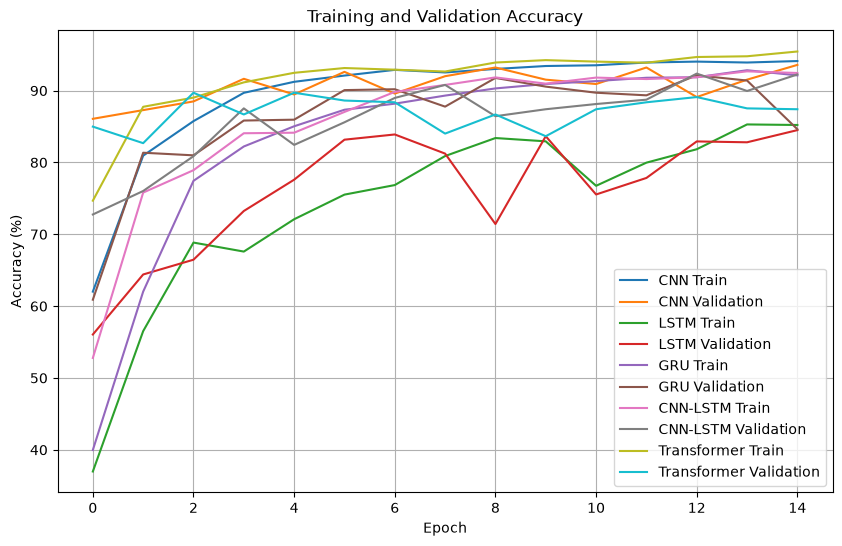

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    cnn_history["train_accuracies"],
    label="CNN Train"
)
plt.plot(
    cnn_history["val_accuracies"],
    label="CNN Validation"
)

plt.plot(
    lstm_history["train_accuracies"],
    label="LSTM Train"
)
plt.plot(
    lstm_history["val_accuracies"],
    label="LSTM Validation"
)

plt.plot(
    gru_history["train_accuracies"],
    label="GRU Train"
)
plt.plot(
    gru_history["val_accuracies"],
    label="GRU Validation"
)

plt.plot(
    cnn_lstm_history["train_accuracies"],
    label="CNN-LSTM Train"
)
plt.plot(
    cnn_lstm_history["val_accuracies"],
    label="CNN-LSTM Validation"
)

plt.plot(
    transformer_history["train_accuracies"],
    label="Transformer Train"
)
plt.plot(
    transformer_history["val_accuracies"],
    label="Transformer Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

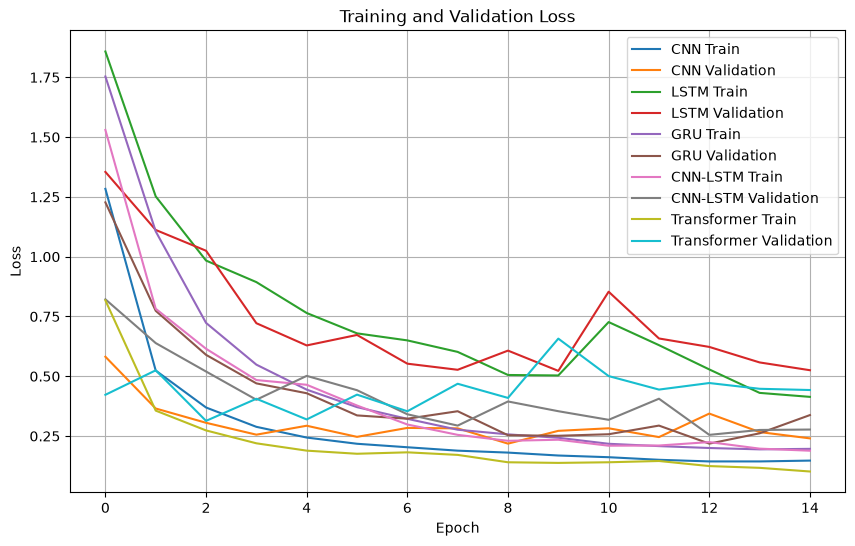

In [62]:
plt.figure(figsize=(10, 6))

plt.plot(
    cnn_history["train_losses"],
    label="CNN Train"
)
plt.plot(
    cnn_history["val_losses"],
    label="CNN Validation"
)

plt.plot(
    lstm_history["train_losses"],
    label="LSTM Train"
)
plt.plot(
    lstm_history["val_losses"],
    label="LSTM Validation"
)

plt.plot(
    gru_history["train_losses"],
    label="GRU Train"
)
plt.plot(
    gru_history["val_losses"],
    label="GRU Validation"
)

plt.plot(
    cnn_lstm_history["train_losses"],
    label="CNN-LSTM Train"
)
plt.plot(
    cnn_lstm_history["val_losses"],
    label="CNN-LSTM Validation"
)

plt.plot(
    transformer_history["train_losses"],
    label="Transformer Train"
)
plt.plot(
    transformer_history["val_losses"],
    label="Transformer Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [63]:
# Function to get predictions from a model

def get_predictions(model, loader):

    model.eval()

    predictions = []
    labels = []

    with torch.no_grad():

        for inputs, batch_labels in loader:

            inputs = inputs.to(device)

            outputs = model(inputs)

            batch_predictions = torch.argmax(
                outputs,
                dim=1
            )

            predictions.extend(
                batch_predictions.cpu().numpy()
            )

            labels.extend(
                batch_labels.numpy()
            )

    return np.array(labels), np.array(predictions)


# Get predictions for all models

cnn_labels, cnn_predictions = get_predictions(
    cnn_model,
    test_loader
)

lstm_labels, lstm_predictions = get_predictions(
    lstm_model,
    test_loader
)

gru_labels, gru_predictions = get_predictions(
    gru_model,
    test_loader
)

cnn_lstm_labels, cnn_lstm_predictions = get_predictions(
    cnn_lstm_model,
    test_loader
)

transformer_labels, transformer_predictions = get_predictions(
    transformer_model,
    test_loader
)

print("Predictions generated successfully!")

print("CNN:", len(cnn_predictions))
print("LSTM:", len(lstm_predictions))
print("GRU:", len(gru_predictions))
print("CNN-LSTM:", len(cnn_lstm_predictions))
print("Transformer:", len(transformer_predictions))

Predictions generated successfully!
CNN: 1037
LSTM: 1037
GRU: 1037
CNN-LSTM: 1037
Transformer: 1037


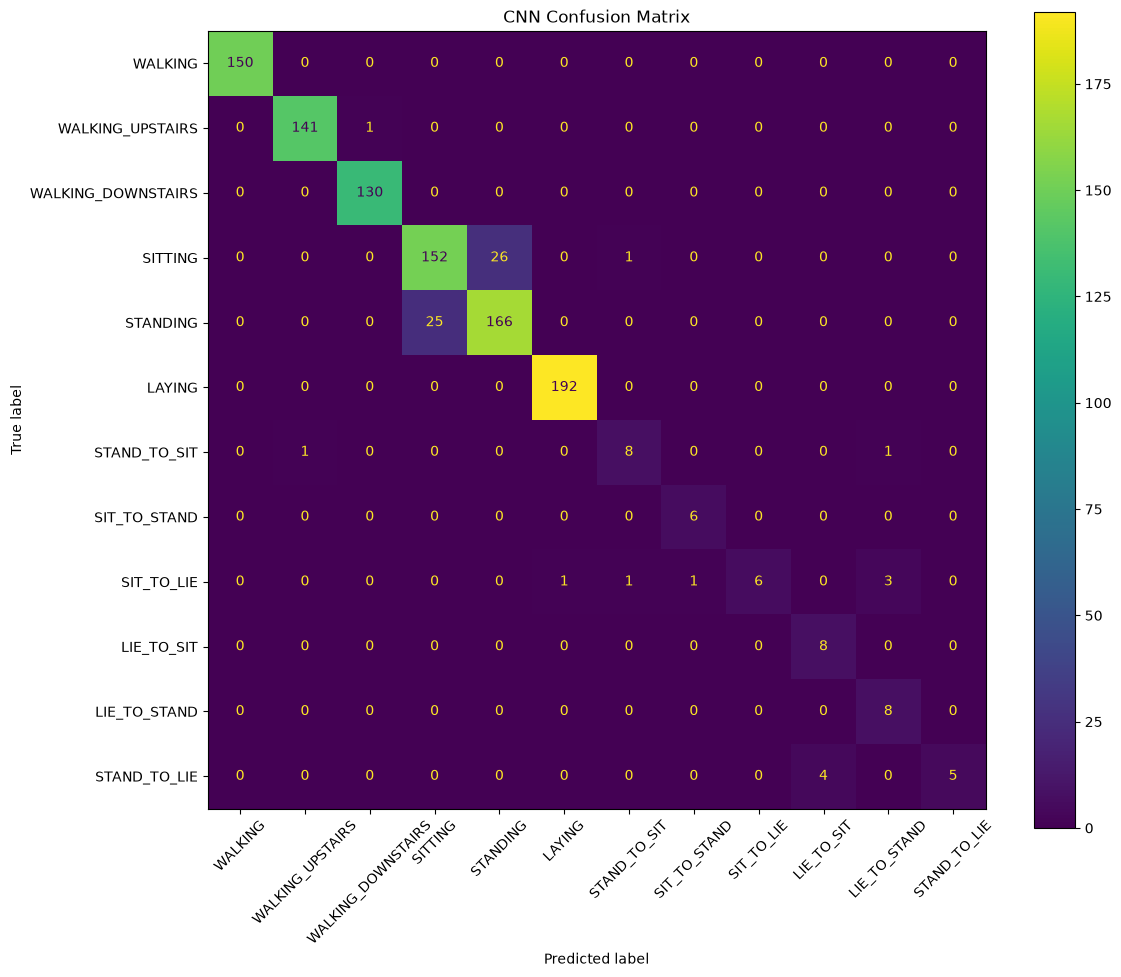

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay

# Class names
class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
    "STAND_TO_SIT",
    "SIT_TO_STAND",
    "SIT_TO_LIE",
    "LIE_TO_SIT",
    "LIE_TO_STAND",
    "STAND_TO_LIE"
]

# Create confusion matrix
cnn_cm = confusion_matrix(
    cnn_labels,
    cnn_predictions
)

# Display
plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cnn_cm,
    display_labels=class_names
)

disp.plot(
    ax=plt.gca(),
    xticks_rotation=45
)

plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()

In [65]:
cnn_report = classification_report(
    cnn_labels,
    cnn_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("CNN Classification Report:\n")
print(cnn_report)

CNN Classification Report:

                    precision    recall  f1-score   support

           WALKING     1.0000    1.0000    1.0000       150
  WALKING_UPSTAIRS     0.9930    0.9930    0.9930       142
WALKING_DOWNSTAIRS     0.9924    1.0000    0.9962       130
           SITTING     0.8588    0.8492    0.8539       179
          STANDING     0.8646    0.8691    0.8668       191
            LAYING     0.9948    1.0000    0.9974       192
      STAND_TO_SIT     0.8000    0.8000    0.8000        10
      SIT_TO_STAND     0.8571    1.0000    0.9231         6
        SIT_TO_LIE     1.0000    0.5000    0.6667        12
        LIE_TO_SIT     0.6667    1.0000    0.8000         8
      LIE_TO_STAND     0.6667    1.0000    0.8000         8
      STAND_TO_LIE     1.0000    0.5556    0.7143         9

          accuracy                         0.9373      1037
         macro avg     0.8912    0.8806    0.8676      1037
      weighted avg     0.9399    0.9373    0.9365      1037



In [66]:
# Classification reports for all five models

reports = {}

reports["CNN"] = classification_report(
    cnn_labels,
    cnn_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

reports["LSTM"] = classification_report(
    lstm_labels,
    lstm_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

reports["GRU"] = classification_report(
    gru_labels,
    gru_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

reports["CNN-LSTM"] = classification_report(
    cnn_lstm_labels,
    cnn_lstm_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

reports["Transformer"] = classification_report(
    transformer_labels,
    transformer_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

print("Classification reports generated for all 5 models!")

Classification reports generated for all 5 models!


In [67]:
# Compare macro and weighted F1-score for all models

model_names = [
    "CNN",
    "LSTM",
    "GRU",
    "CNN-LSTM",
    "Transformer"
]

macro_f1_scores = [
    reports["CNN"]["macro avg"]["f1-score"],
    reports["LSTM"]["macro avg"]["f1-score"],
    reports["GRU"]["macro avg"]["f1-score"],
    reports["CNN-LSTM"]["macro avg"]["f1-score"],
    reports["Transformer"]["macro avg"]["f1-score"]
]

weighted_f1_scores = [
    reports["CNN"]["weighted avg"]["f1-score"],
    reports["LSTM"]["weighted avg"]["f1-score"],
    reports["GRU"]["weighted avg"]["f1-score"],
    reports["CNN-LSTM"]["weighted avg"]["f1-score"],
    reports["Transformer"]["weighted avg"]["f1-score"]
]

print("F1-Score Comparison:\n")

for i, model in enumerate(model_names):

    print(
        f"{model}: "
        f"Macro F1 = {macro_f1_scores[i] * 100:.2f}% | "
        f"Weighted F1 = {weighted_f1_scores[i] * 100:.2f}%"
    )

F1-Score Comparison:

CNN: Macro F1 = 86.76% | Weighted F1 = 93.65%
LSTM: Macro F1 = 57.60% | Weighted F1 = 87.65%
GRU: Macro F1 = 73.92% | Weighted F1 = 86.40%
CNN-LSTM: Macro F1 = 79.60% | Weighted F1 = 92.83%
Transformer: Macro F1 = 69.73% | Weighted F1 = 90.52%


In [68]:
# Per-class F1-score comparison

print("Per-Class F1-Score Comparison\n")

for class_name in class_names:

    print(f"\n{class_name}")

    for model in model_names:

        f1 = reports[model][class_name]["f1-score"]

        print(
            f"  {model:<12} {f1 * 100:.2f}%"
        )

Per-Class F1-Score Comparison


WALKING
  CNN          100.00%
  LSTM         90.22%
  GRU          94.90%
  CNN-LSTM     99.00%
  Transformer  94.57%

WALKING_UPSTAIRS
  CNN          99.30%
  LSTM         93.66%
  GRU          98.59%
  CNN-LSTM     97.22%
  Transformer  98.95%

WALKING_DOWNSTAIRS
  CNN          99.62%
  LSTM         91.87%
  GRU          94.74%
  CNN-LSTM     97.67%
  Transformer  94.31%

SITTING
  CNN          85.39%
  LSTM         85.25%
  GRU          75.30%
  CNN-LSTM     87.05%
  Transformer  86.10%

STANDING
  CNN          86.68%
  LSTM         86.70%
  GRU          69.75%
  CNN-LSTM     87.83%
  Transformer  86.93%

LAYING
  CNN          99.74%
  LSTM         99.22%
  GRU          99.74%
  CNN-LSTM     99.74%
  Transformer  99.74%

STAND_TO_SIT
  CNN          80.00%
  LSTM         16.67%
  GRU          85.71%
  CNN-LSTM     90.00%
  Transformer  76.19%

SIT_TO_STAND
  CNN          92.31%
  LSTM         0.00%
  GRU          66.67%
  CNN-LSTM     72.73%
  Transfo

In [69]:
# Find the best model for each activity

print("Best Model for Each Activity")
print("=" * 60)

for class_name in class_names:

    scores = {
        model: reports[model][class_name]["f1-score"]
        for model in model_names
    }

    best_model = max(
        scores,
        key=scores.get
    )

    best_score = scores[best_model] * 100

    print(
        f"{class_name:<22} "
        f"{best_model:<12} "
        f"{best_score:.2f}%"
    )

Best Model for Each Activity
WALKING                CNN          100.00%
WALKING_UPSTAIRS       CNN          99.30%
WALKING_DOWNSTAIRS     CNN          99.62%
SITTING                CNN-LSTM     87.05%
STANDING               CNN-LSTM     87.83%
LAYING                 CNN          99.74%
STAND_TO_SIT           CNN-LSTM     90.00%
SIT_TO_STAND           CNN          92.31%
SIT_TO_LIE             CNN          66.67%
LIE_TO_SIT             CNN          80.00%
LIE_TO_STAND           CNN          80.00%
STAND_TO_LIE           CNN          71.43%


In [70]:
# Sensor ablation experiment
# Split the 6 sensor features into:
# 0-2 = Accelerometer
# 3-5 = Gyroscope

X_train_acc = X_train[:, :, :3]
X_val_acc = X_val[:, :, :3]
X_test_acc = X_test[:, :, :3]

X_train_gyro = X_train[:, :, 3:]
X_val_gyro = X_val[:, :, 3:]
X_test_gyro = X_test[:, :, 3:]

print("Accelerometer:")
print("X_train:", X_train_acc.shape)
print("X_val:", X_val_acc.shape)
print("X_test:", X_test_acc.shape)

print("\nGyroscope:")
print("X_train:", X_train_gyro.shape)
print("X_val:", X_val_gyro.shape)
print("X_test:", X_test_gyro.shape)

print("\nBoth sensors:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

Accelerometer:
X_train: (3910, 128, 3)
X_val: (826, 128, 3)
X_test: (1037, 128, 3)

Gyroscope:
X_train: (3910, 128, 3)
X_val: (826, 128, 3)
X_test: (1037, 128, 3)

Both sensors:
X_train: (3910, 128, 6)
X_val: (826, 128, 6)
X_test: (1037, 128, 6)


In [72]:
from torch.utils.data import TensorDataset, DataLoader

# Convert labels to PyTorch tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


# Convert accelerometer data
X_train_acc_tensor = torch.tensor(X_train_acc, dtype=torch.float32)
X_val_acc_tensor = torch.tensor(X_val_acc, dtype=torch.float32)
X_test_acc_tensor = torch.tensor(X_test_acc, dtype=torch.float32)


# Convert gyroscope data
X_train_gyro_tensor = torch.tensor(X_train_gyro, dtype=torch.float32)
X_val_gyro_tensor = torch.tensor(X_val_gyro, dtype=torch.float32)
X_test_gyro_tensor = torch.tensor(X_test_gyro, dtype=torch.float32)


# -------------------------
# Accelerometer datasets
# -------------------------

acc_train_dataset = TensorDataset(
    X_train_acc_tensor,
    y_train_tensor
)

acc_val_dataset = TensorDataset(
    X_val_acc_tensor,
    y_val_tensor
)

acc_test_dataset = TensorDataset(
    X_test_acc_tensor,
    y_test_tensor
)


# -------------------------
# Gyroscope datasets
# -------------------------

gyro_train_dataset = TensorDataset(
    X_train_gyro_tensor,
    y_train_tensor
)

gyro_val_dataset = TensorDataset(
    X_val_gyro_tensor,
    y_val_tensor
)

gyro_test_dataset = TensorDataset(
    X_test_gyro_tensor,
    y_test_tensor
)


# -------------------------
# DataLoaders
# -------------------------

acc_train_loader = DataLoader(
    acc_train_dataset,
    batch_size=64,
    shuffle=True
)

acc_val_loader = DataLoader(
    acc_val_dataset,
    batch_size=64,
    shuffle=False
)

acc_test_loader = DataLoader(
    acc_test_dataset,
    batch_size=64,
    shuffle=False
)


gyro_train_loader = DataLoader(
    gyro_train_dataset,
    batch_size=64,
    shuffle=True
)

gyro_val_loader = DataLoader(
    gyro_val_dataset,
    batch_size=64,
    shuffle=False
)

gyro_test_loader = DataLoader(
    gyro_test_dataset,
    batch_size=64,
    shuffle=False
)


print("Sensor-specific DataLoaders created!")

print("\nAccelerometer batches:")
print("Train:", len(acc_train_loader))
print("Validation:", len(acc_val_loader))
print("Test:", len(acc_test_loader))

print("\nGyroscope batches:")
print("Train:", len(gyro_train_loader))
print("Validation:", len(acc_val_loader))
print("Test:", len(acc_test_loader))

Sensor-specific DataLoaders created!

Accelerometer batches:
Train: 62
Validation: 13
Test: 17

Gyroscope batches:
Train: 62
Validation: 13
Test: 17


In [73]:
class CNN_Accelerometer(nn.Module):
    def __init__(self, num_classes=12):
        super(CNN_Accelerometer, self).__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                3,
                64,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),

            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                64,
                128,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),

            nn.MaxPool1d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        # [batch, time, features]
        # → [batch, features, time]

        x = x.transpose(1, 2)

        x = self.features(x)

        x = self.classifier(x)

        return x


acc_model = CNN_Accelerometer().to(device)

print(acc_model)

CNN_Accelerometer(
  (features): Sequential(
    (0): Conv1d(3, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=12, bias=True)
  )
)


In [74]:
class CNN_Accelerometer(nn.Module):
    def __init__(self, num_classes=12):
        super(CNN_Accelerometer, self).__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                3,
                64,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),

            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                64,
                128,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),

            nn.MaxPool1d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        # [batch, time, features]
        # → [batch, features, time]

        x = x.transpose(1, 2)

        x = self.features(x)

        x = self.classifier(x)

        return x


acc_model = CNN_Accelerometer().to(device)

print(acc_model)

CNN_Accelerometer(
  (features): Sequential(
    (0): Conv1d(3, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=12, bias=True)
  )
)


In [75]:
acc_params = sum(
    p.numel()
    for p in acc_model.parameters()
    if p.requires_grad
)

print("Accelerometer CNN Trainable Parameters:", acc_params)

Accelerometer CNN Trainable Parameters: 43660


In [76]:
class CNN_Gyroscope(nn.Module):
    def __init__(self, num_classes=12):
        super(CNN_Gyroscope, self).__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                3,
                64,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),

            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                64,
                128,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),

            nn.MaxPool1d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        # [batch, time, features]
        # → [batch, features, time]

        x = x.transpose(1, 2)

        x = self.features(x)

        x = self.classifier(x)

        return x


gyro_model = CNN_Gyroscope().to(device)

print(gyro_model)

CNN_Gyroscope(
  (features): Sequential(
    (0): Conv1d(3, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=12, bias=True)
  )
)


In [77]:
gyro_params = sum(
    p.numel()
    for p in gyro_model.parameters()
    if p.requires_grad
)

print("Gyroscope CNN Trainable Parameters:", gyro_params)

Gyroscope CNN Trainable Parameters: 43660


In [78]:
# Test accelerometer-only CNN

sample_acc, label_acc = next(iter(acc_train_loader))
sample_acc = sample_acc.to(device)

with torch.no_grad():
    acc_output = acc_model(sample_acc)

print("Accelerometer input:", sample_acc.shape)
print("Accelerometer output:", acc_output.shape)


# Test gyroscope-only CNN

sample_gyro, label_gyro = next(iter(gyro_train_loader))
sample_gyro = sample_gyro.to(device)

with torch.no_grad():
    gyro_output = gyro_model(sample_gyro)

print("\nGyroscope input:", sample_gyro.shape)
print("Gyroscope output:", gyro_output.shape)

Accelerometer input: torch.Size([64, 128, 3])
Accelerometer output: torch.Size([64, 12])

Gyroscope input: torch.Size([64, 128, 3])
Gyroscope output: torch.Size([64, 12])


In [79]:
# Loss and optimizer for accelerometer-only CNN

acc_criterion = nn.CrossEntropyLoss()

acc_optimizer = optim.Adam(
    acc_model.parameters(),
    lr=0.001
)

print("Accelerometer CNN loss:", acc_criterion)
print("Accelerometer CNN optimizer:", acc_optimizer)

Accelerometer CNN loss: CrossEntropyLoss()
Accelerometer CNN optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [80]:
# Train accelerometer-only CNN

start_time = time.time()

acc_history = train_model(
    acc_model,
    acc_train_loader,
    acc_val_loader,
    acc_criterion,
    acc_optimizer,
    epochs=15
)

acc_training_time = time.time() - start_time

print("\nAccelerometer CNN Training completed!")
print(f"Training time: {acc_training_time:.2f} seconds")

Epoch [1/15] Loss: 1.4573 Train Acc: 51.53% Val Loss: 0.9516 Val Acc: 69.13%
Epoch [2/15] Loss: 0.8527 Train Acc: 72.81% Val Loss: 0.7136 Val Acc: 73.61%
Epoch [3/15] Loss: 0.6293 Train Acc: 78.67% Val Loss: 0.6518 Val Acc: 76.51%
Epoch [4/15] Loss: 0.5322 Train Acc: 81.69% Val Loss: 0.5472 Val Acc: 79.54%
Epoch [5/15] Loss: 0.4723 Train Acc: 83.84% Val Loss: 0.5540 Val Acc: 78.69%
Epoch [6/15] Loss: 0.4316 Train Acc: 85.32% Val Loss: 0.5204 Val Acc: 80.99%
Epoch [7/15] Loss: 0.3841 Train Acc: 87.26% Val Loss: 0.4407 Val Acc: 84.38%
Epoch [8/15] Loss: 0.3717 Train Acc: 87.57% Val Loss: 0.5008 Val Acc: 83.17%
Epoch [9/15] Loss: 0.3369 Train Acc: 88.82% Val Loss: 0.5065 Val Acc: 79.66%
Epoch [10/15] Loss: 0.3202 Train Acc: 88.77% Val Loss: 0.4857 Val Acc: 83.78%
Epoch [11/15] Loss: 0.3008 Train Acc: 89.69% Val Loss: 0.4258 Val Acc: 87.05%
Epoch [12/15] Loss: 0.2808 Train Acc: 90.41% Val Loss: 0.4697 Val Acc: 82.93%
Epoch [13/15] Loss: 0.2717 Train Acc: 90.43% Val Loss: 0.4309 Val Acc: 86

In [81]:
# Evaluate Accelerometer-only CNN

acc_model.eval()

acc_predictions = []
acc_labels = []

start_time = time.time()

with torch.no_grad():

    for inputs, labels in acc_test_loader:

        inputs = inputs.to(device)

        outputs = acc_model(inputs)

        predictions = torch.argmax(outputs, dim=1)

        acc_predictions.extend(
            predictions.cpu().numpy()
        )

        acc_labels.extend(
            labels.numpy()
        )

acc_inference_time = time.time() - start_time

# Metrics
acc_test_accuracy = accuracy_score(
    acc_labels,
    acc_predictions
)

acc_precision = precision_score(
    acc_labels,
    acc_predictions,
    average="weighted",
    zero_division=0
)

acc_recall = recall_score(
    acc_labels,
    acc_predictions,
    average="weighted",
    zero_division=0
)

acc_f1 = f1_score(
    acc_labels,
    acc_predictions,
    average="weighted",
    zero_division=0
)

print(f"Accelerometer CNN Test Accuracy: {acc_test_accuracy * 100:.2f}%")
print(f"Accelerometer CNN Precision: {acc_precision * 100:.2f}%")
print(f"Accelerometer CNN Recall: {acc_recall * 100:.2f}%")
print(f"Accelerometer CNN F1-Score: {acc_f1 * 100:.2f}%")
print(f"Accelerometer CNN Inference Time: {acc_inference_time:.4f} seconds")

Accelerometer CNN Test Accuracy: 91.90%
Accelerometer CNN Precision: 91.73%
Accelerometer CNN Recall: 91.90%
Accelerometer CNN F1-Score: 91.23%
Accelerometer CNN Inference Time: 0.3307 seconds


In [82]:
gyro_criterion = nn.CrossEntropyLoss()

gyro_optimizer = optim.Adam(
    gyro_model.parameters(),
    lr=0.001
)

print("Gyroscope CNN loss:", gyro_criterion)
print("Gyroscope CNN optimizer:", gyro_optimizer)

Gyroscope CNN loss: CrossEntropyLoss()
Gyroscope CNN optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [83]:
# Train gyroscope-only CNN

start_time = time.time()

gyro_history = train_model(
    gyro_model,
    gyro_train_loader,
    gyro_val_loader,
    gyro_criterion,
    gyro_optimizer,
    epochs=15
)

gyro_training_time = time.time() - start_time

print("\nGyroscope CNN Training completed!")
print(f"Training time: {gyro_training_time:.2f} seconds")

Epoch [1/15] Loss: 1.6355 Train Acc: 42.12% Val Loss: 1.0984 Val Acc: 50.85%
Epoch [2/15] Loss: 1.0311 Train Acc: 52.20% Val Loss: 0.9402 Val Acc: 53.63%
Epoch [3/15] Loss: 0.9176 Train Acc: 54.02% Val Loss: 0.8902 Val Acc: 56.90%
Epoch [4/15] Loss: 0.8492 Train Acc: 59.03% Val Loss: 0.8631 Val Acc: 56.90%
Epoch [5/15] Loss: 0.8193 Train Acc: 59.36% Val Loss: 0.8445 Val Acc: 57.87%
Epoch [6/15] Loss: 0.7881 Train Acc: 60.90% Val Loss: 0.8355 Val Acc: 58.35%
Epoch [7/15] Loss: 0.7722 Train Acc: 61.94% Val Loss: 0.8072 Val Acc: 60.53%
Epoch [8/15] Loss: 0.7472 Train Acc: 64.53% Val Loss: 0.7879 Val Acc: 60.90%
Epoch [9/15] Loss: 0.7260 Train Acc: 65.27% Val Loss: 0.7722 Val Acc: 62.71%
Epoch [10/15] Loss: 0.6976 Train Acc: 66.57% Val Loss: 0.7721 Val Acc: 68.04%
Epoch [11/15] Loss: 0.6868 Train Acc: 66.73% Val Loss: 0.7742 Val Acc: 61.50%
Epoch [12/15] Loss: 0.6805 Train Acc: 68.08% Val Loss: 0.7459 Val Acc: 68.04%
Epoch [13/15] Loss: 0.6557 Train Acc: 69.87% Val Loss: 0.7514 Val Acc: 70

In [84]:
# Evaluate Gyroscope-only CNN

gyro_model.eval()

gyro_predictions = []
gyro_labels = []

start_time = time.time()

with torch.no_grad():

    for inputs, labels in gyro_test_loader:

        inputs = inputs.to(device)

        outputs = gyro_model(inputs)

        predictions = torch.argmax(outputs, dim=1)

        gyro_predictions.extend(
            predictions.cpu().numpy()
        )

        gyro_labels.extend(
            labels.numpy()
        )

gyro_inference_time = time.time() - start_time

# Metrics
gyro_test_accuracy = accuracy_score(
    gyro_labels,
    gyro_predictions
)

gyro_precision = precision_score(
    gyro_labels,
    gyro_predictions,
    average="weighted",
    zero_division=0
)

gyro_recall = recall_score(
    gyro_labels,
    gyro_predictions,
    average="weighted",
    zero_division=0
)

gyro_f1 = f1_score(
    gyro_labels,
    gyro_predictions,
    average="weighted",
    zero_division=0
)

print(f"Gyroscope CNN Test Accuracy: {gyro_test_accuracy * 100:.2f}%")
print(f"Gyroscope CNN Precision: {gyro_precision * 100:.2f}%")
print(f"Gyroscope CNN Recall: {gyro_recall * 100:.2f}%")
print(f"Gyroscope CNN F1-Score: {gyro_f1 * 100:.2f}%")
print(f"Gyroscope CNN Inference Time: {gyro_inference_time:.4f} seconds")

Gyroscope CNN Test Accuracy: 72.23%
Gyroscope CNN Precision: 74.37%
Gyroscope CNN Recall: 72.23%
Gyroscope CNN F1-Score: 69.77%
Gyroscope CNN Inference Time: 0.1582 seconds


In [85]:
# Classification reports for sensor ablation

acc_report = classification_report(
    acc_labels,
    acc_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

gyro_report = classification_report(
    gyro_labels,
    gyro_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# Full CNN report already exists as reports["CNN"]

print("Sensor Ablation F1-Score\n")

print(
    f"Accelerometer only - "
    f"Macro F1: {acc_report['macro avg']['f1-score'] * 100:.2f}% | "
    f"Weighted F1: {acc_report['weighted avg']['f1-score'] * 100:.2f}%"
)

print(
    f"Gyroscope only     - "
    f"Macro F1: {gyro_report['macro avg']['f1-score'] * 100:.2f}% | "
    f"Weighted F1: {gyro_report['weighted avg']['f1-score'] * 100:.2f}%"
)

print(
    f"Both sensors       - "
    f"Macro F1: {reports['CNN']['macro avg']['f1-score'] * 100:.2f}% | "
    f"Weighted F1: {reports['CNN']['weighted avg']['f1-score'] * 100:.2f}%"
)

Sensor Ablation F1-Score

Accelerometer only - Macro F1: 69.14% | Weighted F1: 91.23%
Gyroscope only     - Macro F1: 66.89% | Weighted F1: 69.77%
Both sensors       - Macro F1: 86.76% | Weighted F1: 93.65%


In [87]:
sensor_ablation_results = {
    "Accelerometer Only": {
        "Parameters": acc_params,
        "Training Time (s)": acc_training_time,
        "Test Accuracy (%)": acc_test_accuracy * 100,
        "Precision (%)": acc_precision * 100,
        "Recall (%)": acc_recall * 100,
        "F1-Score (%)": acc_f1 * 100,
        "Macro F1 (%)": acc_report["macro avg"]["f1-score"] * 100,
        "Inference Time (s)": acc_inference_time
    },

    "Gyroscope Only": {
        "Parameters": gyro_params,
        "Training Time (s)": gyro_training_time,
        "Test Accuracy (%)": gyro_test_accuracy * 100,
        "Precision (%)": gyro_precision * 100,
        "Recall (%)": gyro_recall * 100,
        "F1-Score (%)": gyro_f1 * 100,
        "Macro F1 (%)": gyro_report["macro avg"]["f1-score"] * 100,
        "Inference Time (s)": gyro_inference_time
    },

    "Both Sensors": {
        "Parameters": 44620,
        "Training Time (s)": cnn_training_time,
        "Test Accuracy (%)": cnn_test_accuracy * 100,
        "Precision (%)": cnn_precision * 100,
        "Recall (%)": cnn_recall * 100,
        "F1-Score (%)": cnn_f1 * 100,
        "Macro F1 (%)": reports["CNN"]["macro avg"]["f1-score"] * 100,
        "Inference Time (s)": cnn_inference_time
    }
}

print("Sensor ablation results saved!")

for sensor, results in sensor_ablation_results.items():
    print(f"\n{sensor}:")
    print(results)

Sensor ablation results saved!

Accelerometer Only:
{'Parameters': 43660, 'Training Time (s)': 32.640236139297485, 'Test Accuracy (%)': 91.8997107039537, 'Precision (%)': 91.73157755432251, 'Recall (%)': 91.8997107039537, 'F1-Score (%)': 91.23150662145248, 'Macro F1 (%)': 69.14447358198586, 'Inference Time (s)': 0.33067774772644043}

Gyroscope Only:
{'Parameters': 43660, 'Training Time (s)': 32.91010284423828, 'Test Accuracy (%)': 72.22757955641272, 'Precision (%)': 74.37070428640178, 'Recall (%)': 72.22757955641272, 'F1-Score (%)': 69.76795955635102, 'Macro F1 (%)': 66.88557369531037, 'Inference Time (s)': 0.15817689895629883}

Both Sensors:
{'Parameters': 44620, 'Training Time (s)': 32.44960975646973, 'Test Accuracy (%)': 93.73191899710704, 'Precision (%)': 93.9899006302238, 'Recall (%)': 93.73191899710704, 'F1-Score (%)': 93.65388231397091, 'Macro F1 (%)': 86.76109621355343, 'Inference Time (s)': 0.23010993003845215}


In [88]:
# Complete model efficiency comparison

model_results = [
    {
        "Model": "CNN",
        "Parameters": 44620,
        "Test Accuracy": 93.7319,
        "Macro F1": 86.7611,
        "Training Time": 32.4496,
        "Inference Time": 0.2301
    },
    {
        "Model": "LSTM",
        "Parameters": 52492,
        "Test Accuracy": 88.4282,
        "Macro F1": 57.5968,
        "Training Time": 41.0562,
        "Inference Time": 0.2092
    },
    {
        "Model": "GRU",
        "Parameters": 39564,
        "Test Accuracy": 86.6914,
        "Macro F1": 73.9238,
        "Training Time": 149.7399,
        "Inference Time": 0.5538
    },
    {
        "Model": "CNN-LSTM",
        "Parameters": 89868,
        "Test Accuracy": 92.9624,
        "Macro F1": 79.5964,
        "Training Time": 29.45,
        "Inference Time": 0.1790
    },
    {
        "Model": "Transformer",
        "Parameters": 563532,
        "Test Accuracy": 91.13,
        "Macro F1": 69.73,
        "Training Time": 2295.26,
        "Inference Time": 2.3592
    }
]

print("Complete Model Comparison\n")
print("=" * 90)

for result in model_results:

    print(
        f"{result['Model']:<12} | "
        f"Accuracy: {result['Test Accuracy']:.2f}% | "
        f"Macro F1: {result['Macro F1']:.2f}% | "
        f"Parameters: {result['Parameters']:,} | "
        f"Train: {result['Training Time']:.2f}s | "
        f"Inference: {result['Inference Time']:.4f}s"
    )

Complete Model Comparison

CNN          | Accuracy: 93.73% | Macro F1: 86.76% | Parameters: 44,620 | Train: 32.45s | Inference: 0.2301s
LSTM         | Accuracy: 88.43% | Macro F1: 57.60% | Parameters: 52,492 | Train: 41.06s | Inference: 0.2092s
GRU          | Accuracy: 86.69% | Macro F1: 73.92% | Parameters: 39,564 | Train: 149.74s | Inference: 0.5538s
CNN-LSTM     | Accuracy: 92.96% | Macro F1: 79.60% | Parameters: 89,868 | Train: 29.45s | Inference: 0.1790s
Transformer  | Accuracy: 91.13% | Macro F1: 69.73% | Parameters: 563,532 | Train: 2295.26s | Inference: 2.3592s


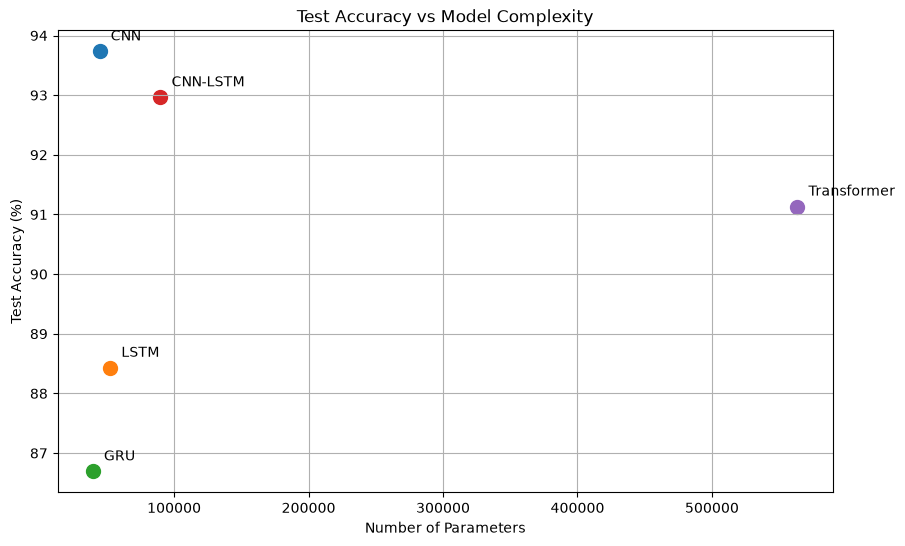

In [89]:
# Accuracy vs number of parameters

plt.figure(figsize=(10, 6))

for result in model_results:

    plt.scatter(
        result["Parameters"],
        result["Test Accuracy"],
        s=100
    )

    plt.annotate(
        result["Model"],
        (
            result["Parameters"],
            result["Test Accuracy"]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("Number of Parameters")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy vs Model Complexity")
plt.grid(True)

plt.show()

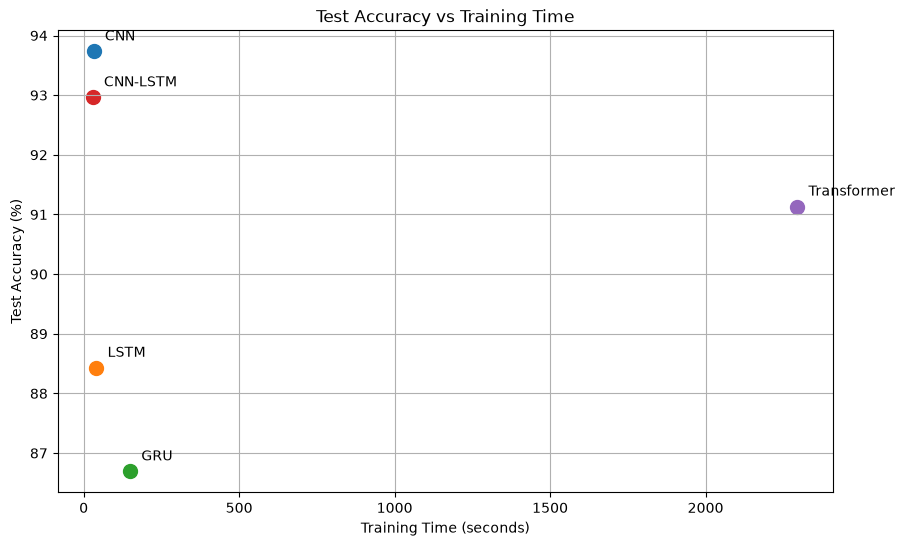

In [90]:
# Test Accuracy vs Training Time

plt.figure(figsize=(10, 6))

for result in model_results:

    plt.scatter(
        result["Training Time"],
        result["Test Accuracy"],
        s=100
    )

    plt.annotate(
        result["Model"],
        (
            result["Training Time"],
            result["Test Accuracy"]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("Training Time (seconds)")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy vs Training Time")
plt.grid(True)

plt.show()

In [91]:
# Final model comparison table

final_results = pd.DataFrame([
    {
        "Model": "CNN",
        "Parameters": 44620,
        "Training Time (s)": 32.4496,
        "Test Accuracy (%)": 93.7319,
        "Precision (%)": 93.9899,
        "Recall (%)": 93.7319,
        "F1-Score (%)": 93.6539,
        "Macro F1 (%)": 86.7611,
        "Inference Time (s)": 0.2301
    },
    {
        "Model": "LSTM",
        "Parameters": 52492,
        "Training Time (s)": 41.0562,
        "Test Accuracy (%)": 88.4282,
        "Precision (%)": 87.8259,
        "Recall (%)": 88.4282,
        "F1-Score (%)": 87.6540,
        "Macro F1 (%)": 57.5968,
        "Inference Time (s)": 0.2092
    },
    {
        "Model": "GRU",
        "Parameters": 39564,
        "Training Time (s)": 149.7399,
        "Test Accuracy (%)": 86.6914,
        "Precision (%)": 87.94,
        "Recall (%)": 86.6914,
        "F1-Score (%)": 86.40,
        "Macro F1 (%)": 73.9238,
        "Inference Time (s)": 0.5538
    },
    {
        "Model": "CNN-LSTM",
        "Parameters": 89868,
        "Training Time (s)": 29.45,
        "Test Accuracy (%)": 92.9624,
        "Precision (%)": 93.32,
        "Recall (%)": 92.9624,
        "F1-Score (%)": 92.83,
        "Macro F1 (%)": 79.5964,
        "Inference Time (s)": 0.1790
    },
    {
        "Model": "Transformer",
        "Parameters": 563532,
        "Training Time (s)": 2295.26,
        "Test Accuracy (%)": 91.13,
        "Precision (%)": 90.37,
        "Recall (%)": 91.13,
        "F1-Score (%)": 90.52,
        "Macro F1 (%)": 69.73,
        "Inference Time (s)": 2.3592
    }
])

print("FINAL MODEL RESULTS")
print("=" * 100)
print(final_results.round(2).to_string(index=False))

FINAL MODEL RESULTS
      Model  Parameters  Training Time (s)  Test Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  Macro F1 (%)  Inference Time (s)
        CNN       44620              32.45              93.73          93.99       93.73         93.65         86.76                0.23
       LSTM       52492              41.06              88.43          87.83       88.43         87.65         57.60                0.21
        GRU       39564             149.74              86.69          87.94       86.69         86.40         73.92                0.55
   CNN-LSTM       89868              29.45              92.96          93.32       92.96         92.83         79.60                0.18
Transformer      563532            2295.26              91.13          90.37       91.13         90.52         69.73                2.36


In [92]:
# Final model rankings

ranking = final_results.copy()

ranking["Accuracy Rank"] = (
    ranking["Test Accuracy (%)"]
    .rank(ascending=False, method="min")
    .astype(int)
)

ranking["Macro F1 Rank"] = (
    ranking["Macro F1 (%)"]
    .rank(ascending=False, method="min")
    .astype(int)
)

ranking["Parameter Rank"] = (
    ranking["Parameters"]
    .rank(ascending=True, method="min")
    .astype(int)
)

ranking["Training Time Rank"] = (
    ranking["Training Time (s)"]
    .rank(ascending=True, method="min")
    .astype(int)
)

ranking["Inference Time Rank"] = (
    ranking["Inference Time (s)"]
    .rank(ascending=True, method="min")
    .astype(int)
)

print("FINAL MODEL RANKINGS")
print("=" * 100)

print(
    ranking[
        [
            "Model",
            "Accuracy Rank",
            "Macro F1 Rank",
            "Parameter Rank",
            "Training Time Rank",
            "Inference Time Rank"
        ]
    ]
    .sort_values("Accuracy Rank")
    .to_string(index=False)
)

FINAL MODEL RANKINGS
      Model  Accuracy Rank  Macro F1 Rank  Parameter Rank  Training Time Rank  Inference Time Rank
        CNN              1              1               2                   2                    3
   CNN-LSTM              2              2               4                   1                    1
Transformer              3              4               5                   5                    5
       LSTM              4              5               3                   3                    2
        GRU              5              3               1                   4                    4


In [93]:
# Final Results Table

final_results_display = final_results.copy()

# Round numerical values
final_results_display["Test Accuracy (%)"] = final_results_display["Test Accuracy (%)"].round(2)
final_results_display["Precision (%)"] = final_results_display["Precision (%)"].round(2)
final_results_display["Recall (%)"] = final_results_display["Recall (%)"].round(2)
final_results_display["F1-Score (%)"] = final_results_display["F1-Score (%)"].round(2)
final_results_display["Macro F1 (%)"] = final_results_display["Macro F1 (%)"].round(2)
final_results_display["Training Time (s)"] = final_results_display["Training Time (s)"].round(2)
final_results_display["Inference Time (s)"] = final_results_display["Inference Time (s)"].round(4)

print("FINAL RESULTS TABLE")
display(final_results_display)

FINAL RESULTS TABLE


,Model,Parameters,Training Time (s),Test Accuracy (%),Precision (%),Recall (%),F1-Score (%),Macro F1 (%),Inference Time (s)
0,CNN,44620,32.45,93.73,93.99,93.73,93.65,86.76,0.2301
1,LSTM,52492,41.06,88.43,87.83,88.43,87.65,57.60,0.2092
2,GRU,39564,149.74,86.69,87.94,86.69,86.40,73.92,0.5538
3,CNN-LSTM,89868,29.45,92.96,93.32,92.96,92.83,79.60,0.1790
4,Transformer,563532,2295.26,91.13,90.37,91.13,90.52,69.73,2.3592


In [94]:
# Final Sensor Ablation Table

sensor_results_display = pd.DataFrame([
    {
        "Sensor Configuration": "Accelerometer Only",
        "Parameters": 43660,
        "Training Time (s)": 32.64,
        "Test Accuracy (%)": 91.90,
        "Precision (%)": 91.73,
        "Recall (%)": 91.90,
        "F1-Score (%)": 91.23,
        "Macro F1 (%)": 69.14,
        "Inference Time (s)": 0.3307
    },
    {
        "Sensor Configuration": "Gyroscope Only",
        "Parameters": 43660,
        "Training Time (s)": 32.91,
        "Test Accuracy (%)": 72.23,
        "Precision (%)": 74.37,
        "Recall (%)": 72.23,
        "F1-Score (%)": 69.77,
        "Macro F1 (%)": 66.89,
        "Inference Time (s)": 0.1582
    },
    {
        "Sensor Configuration": "Both Sensors",
        "Parameters": 44620,
        "Training Time (s)": 32.45,
        "Test Accuracy (%)": 93.73,
        "Precision (%)": 93.99,
        "Recall (%)": 93.73,
        "F1-Score (%)": 93.65,
        "Macro F1 (%)": 86.76,
        "Inference Time (s)": 0.2301
    }
])

print("FINAL SENSOR ABLATION RESULTS")
display(sensor_results_display)

FINAL SENSOR ABLATION RESULTS


,Sensor Configuration,Parameters,Training Time (s),Test Accuracy (%),Precision (%),Recall (%),F1-Score (%),Macro F1 (%),Inference Time (s)
0,Accelerometer Only,43660,32.64,91.90,91.73,91.90,91.23,69.14,0.3307
1,Gyroscope Only,43660,32.91,72.23,74.37,72.23,69.77,66.89,0.1582
2,Both Sensors,44620,32.45,93.73,93.99,93.73,93.65,86.76,0.2301
